# Data Exploration

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import kagglehub

path = kagglehub.dataset_download("rajkumarl/people-clothing-segmentation")

100%|██████████| 616M/616M [00:07<00:00, 84.0MB/s]

Extracting files...


In [2]:
print("Path to dataset files:", path)

Path to dataset files: /root/.cache/kagglehub/datasets/rajkumarl/people-clothing-segmentation/versions/2


In [3]:
RAW_DIR = os.path.join(path)
IMAGES_DIR = os.path.join(RAW_DIR, "png_images", "IMAGES")
MASKS_DIR = os.path.join(RAW_DIR, "png_masks", "MASKS")

In [4]:
image_files = sorted(os.listdir(IMAGES_DIR))
mask_files = sorted(os.listdir(MASKS_DIR))

print(f"Images: {len(image_files)}")
print(f"Masks:  {len(mask_files)}")

Images: 1000
Masks:  1000


In [5]:
labels_df = pd.read_csv(os.path.join(RAW_DIR, "labels.csv"))
print(f"# original classes: {len(labels_df)}")
labels_df.head()

# original classes: 59


,Unnamed: 0,label_list
0,0,NaN
1,1,accessories
2,2,bag
3,3,belt
4,4,blazer


## A few sample image / mask pairs

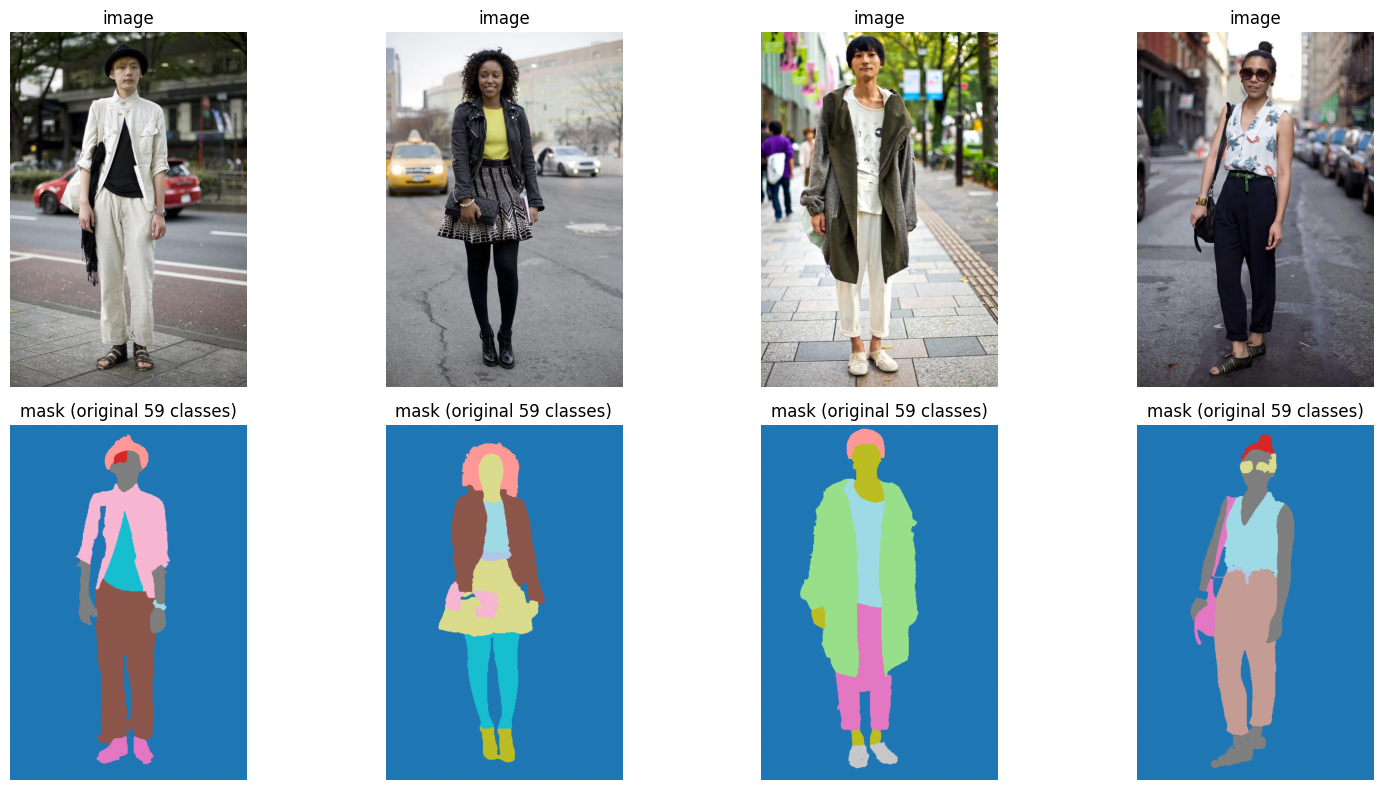

In [8]:
sample_ids = np.random.choice(len(image_files), 4, replace=False)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for col, idx in enumerate(sample_ids):
    image = cv2.cvtColor(cv2.imread(os.path.join(IMAGES_DIR, image_files[idx])), cv2.COLOR_BGR2RGB)
    mask = cv2.imread(os.path.join(MASKS_DIR, mask_files[idx]), cv2.IMREAD_GRAYSCALE)

    axes[0, col].imshow(image)
    axes[0, col].set_title("image")
    axes[0, col].axis("off")

    axes[1, col].imshow(mask, cmap="tab20")
    axes[1, col].set_title("mask (original 59 classes)")
    axes[1, col].axis("off")

plt.tight_layout()
plt.show()

## Image size and mask value sanity check

In [7]:
sample_image = cv2.imread(os.path.join(IMAGES_DIR, image_files[0]))
sample_mask = cv2.imread(os.path.join(MASKS_DIR, mask_files[0]), cv2.IMREAD_GRAYSCALE)

print(f"Image shape: {sample_image.shape}")
print(f"Mask shape:  {sample_mask.shape}")
print(f"Mask unique values (this sample): {sorted(np.unique(sample_mask).tolist())}")
print(f"Mask value range across the whole dataset should be 0-58 (59 classes).")

Image shape: (825, 550, 3)
Mask shape:  (825, 550)
Mask unique values (this sample): [0, 5, 19, 39, 41, 42, 45, 47, 55]
Mask value range across the whole dataset should be 0-58 (59 classes).
